In [9]:
#!pip install pandas numpy matplotlib seaborn scikit-learn nltk joblib
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
#nltk.data.path.append(r"C:\Users\Soon Yik\AI Practical\AI (V2)\nltk_data") #cahnge to ur path if system cant find the folder
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
#from sklearn.svm import SVC
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
print("Downloads complete.")

Downloads complete.


[nltk_data] Downloading package punkt to C:\Users\Soon
[nltk_data]     Yik\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Soon
[nltk_data]     Yik\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Soon
[nltk_data]     Yik\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [2]:
sentiment_df = pd.read_csv('Reddit_Data.csv')
sarcasm_df = pd.read_csv('train-balanced-sarcasm.csv') 
#print('Sentiment dataset count:', sentiment_df.shape)
#print('Sarcasm dataset count:', sarcasm_df.shape)
#sentiment_df.head()

In [3]:
#sarcasm_df.head()

In [4]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = re.sub(r'http\S+|www\S+|@[^\s]+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    tokens = word_tokenize(text)
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(cleaned_tokens)

In [5]:
X_sentiment = sentiment_df['clean_comment']
y_sentiment = sentiment_df['category']

X_sarcasm = sarcasm_df['comment']
y_sarcasm = sarcasm_df['label'] 

In [6]:
# SVM Pipeline
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(preprocessor=preprocess_text, max_df=0.7)),
    ('clf', LinearSVC(class_weight='balanced', random_state=42)) 
])

pipeline_sent = clone(svm_pipeline)
pipeline_sarc = clone(svm_pipeline)

X_sentiment_clean = ['' if pd.isna(text) else text for text in X_sentiment]
X_sarcasm_clean = ['' if pd.isna(text) else text for text in X_sarcasm]

X_train_sent, X_test_sent, y_train_sent, y_test_sent = train_test_split(
    X_sentiment_clean, y_sentiment, test_size=0.2, random_state=42)

X_train_sarc, X_test_sarc, y_train_sarc, y_test_sarc = train_test_split(
    X_sarcasm_clean, y_sarcasm, test_size=0.2, random_state=42)

print("Training Sentiment SVM: (take a while)")
pipeline_sent.fit(X_train_sent, y_train_sent)
y_pred_sent = pipeline_sent.predict(X_test_sent)
print(f"Sentiment Accuracy: {accuracy_score(y_test_sent, y_pred_sent) * 100:.2f}%")
print(classification_report(y_test_sent, y_pred_sent))

print("Training Sarcasm SVM: (take a while)")
pipeline_sarc.fit(X_train_sarc, y_train_sarc)
y_pred_sarc = pipeline_sarc.predict(X_test_sarc)
print(f"Sarcasm Accuracy: {accuracy_score(y_test_sarc, y_pred_sarc) * 100:.2f}%")
print(classification_report(y_test_sarc, y_pred_sarc))

print("Training complete!")

Training Sentiment SVM: (take a while)
Sentiment Accuracy: 85.10%
              precision    recall  f1-score   support

          -1       0.80      0.72      0.76      1667
           0       0.84      0.94      0.89      2615
           1       0.88      0.84      0.86      3168

    accuracy                           0.85      7450
   macro avg       0.84      0.84      0.84      7450
weighted avg       0.85      0.85      0.85      7450

Training Sarcasm SVM: (take a while)
Sarcasm Accuracy: 66.79%
              precision    recall  f1-score   support

           0       0.66      0.70      0.68    101100
           1       0.68      0.64      0.66    101066

    accuracy                           0.67    202166
   macro avg       0.67      0.67      0.67    202166
weighted avg       0.67      0.67      0.67    202166

Training complete!


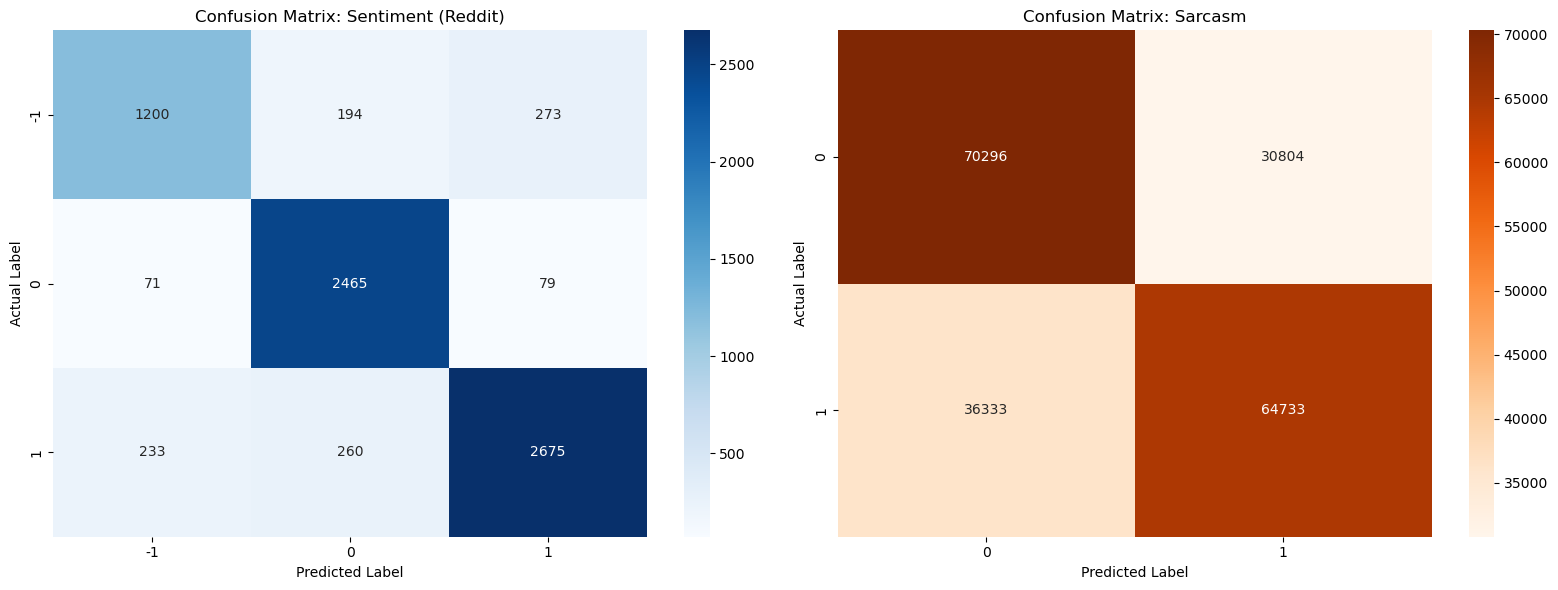

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sentiment Matrix
cm_sent = confusion_matrix(y_test_sent, y_pred_sent, labels=pipeline_sent.classes_)
sns.heatmap(cm_sent, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=pipeline_sent.classes_, yticklabels=pipeline_sent.classes_)
axes[0].set_title('Confusion Matrix: Sentiment (Reddit)')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('Actual Label')

# Sarcasm Matrix
cm_sarc = confusion_matrix(y_test_sarc, y_pred_sarc, labels=pipeline_sarc.classes_)
sns.heatmap(cm_sarc, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=pipeline_sarc.classes_, yticklabels=pipeline_sarc.classes_)
axes[1].set_title('Confusion Matrix: Sarcasm')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('Actual Label')

plt.tight_layout()
plt.show()

In [11]:
joblib.dump(pipeline_sent, 'svm_sentiment_model.pkl')
joblib.dump(pipeline_sarc, 'svm_sarcasm_model.pkl')
print("SVM Models saved!")

SVM Models saved!


In [8]:
def analyze_text(custom_text):
    text_list = [custom_text]
    
    sent_prediction = pipeline_sent.predict(text_list)[0]
    sarc_prediction = pipeline_sarc.predict(text_list)[0]

    sentiment_dict = {-1: "Negative", 0: "Neutral", 1: "Positive"}
    sarcasm_dict = {0: "Not Sarcastic", 1: "Sarcastic"}
    
    print(f"Text Input: \"{custom_text}\"")
    print(f"Sentiment : {sentiment_dict.get(sent_prediction, sent_prediction)} (Label: {sent_prediction})")
    print(f"Sarcasm   : {sarcasm_dict.get(sarc_prediction, sarc_prediction)} (Label: {sarc_prediction})")
    print("\n")

analyze_text("Oh great, the server crashed again. Exactly what I wanted today.")
analyze_text("I absolutely love the new design of this website!")
analyze_text("I went to the store to buy some milk.")

user_typed = input("Enter a sentence to test: ")
analyze_text(user_typed)

Text Input: "Oh great, the server crashed again. Exactly what I wanted today."
Sentiment : Positive (Label: 1)
Sarcasm   : Sarcastic (Label: 1)


Text Input: "I absolutely love the new design of this website!"
Sentiment : Positive (Label: 1)
Sarcasm   : Not Sarcastic (Label: 0)


Text Input: "I went to the store to buy some milk."
Sentiment : Neutral (Label: 0)
Sarcasm   : Not Sarcastic (Label: 0)




Enter a sentence to test:  i dont !like you.


Text Input: "i dont !like you."
Sentiment : Neutral (Label: 0)
Sarcasm   : Not Sarcastic (Label: 0)


